# Importation et charger les corpus

In [1]:
from collections import Counter
import spacy
nlp = spacy.load("fr_core_news_sm")

from datasets import load_dataset
dataset = load_dataset("wikimedia/wikipedia", "20231101.fr", split="train", streaming=True)
dataset = dataset.shuffle(seed=42, buffer_size=10000) # 做近似随机打乱, Effectuer un mélange aléatoire approximatif
# 这里对corpus做打乱是为了在读取文章时不要按照顺序提取词语, 防止我们提取到的词语都是同一个thème的

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

### Observation de la stucture du corpus
在使用dataset之前, 我们先查看一下它的储存结构, 并且看一下是否有一些内容需要被提前清洗 / Avant d'utiliser l'ensemble de données, examinons sa structure de stockage et vérifions si certains contenus doivent être préalablement nettoyés.

In [2]:
iterator = iter(dataset)
article = next(iterator)

# print(type(article)) >>> <class 'dict'>
# print(article.keys()) >>> dict_keys(['id', 'url', 'title', 'text'])
for key, value in article.items():
    print(f"{key} : {value}")

# Deuxième article
article = next(iterator)
for key, value in article.items():
    print(f"{key} : {value}")

id : 12062712
url : https://fr.wikipedia.org/wiki/Archidioc%C3%A8se%20de%20Lecce
title : Archidiocèse de Lecce
text : L' archidiocèse de Lecce (en latin : ) est un archidiocèse métropolitain de l'Église catholique d'Italie appartenant à la région ecclésiastique des Pouilles.

Territoire 
Géographiquement l'archidiocèse se trouve dans une partie de la province de Brindisi et dans la province de Lecce. Son territoire est de  divisé en 77 paroisses regroupées en 4 archidiaconés. Le siège épiscopal est à Lecce où est située la cathédrale de l'Assomption. Dans la même ville se trouve l'église du Gesù qui conserve le corps de saint Bernardin Realino. L'archidiocèse possède 3 basiliques mineures : la basilique de sainte Croix, la basilique Saint Jean-Baptiste et la basilique de Saint Dominique Savio. À Campi Salentina, se trouve le sanctuaire de saint Pompile Marie Pirrotti.

Histoire 

La tradition retrace la fondation du diocèse de Lecce aux temps apostoliques de l'Église, au , Justus de Co

### Nettoyage du corpus
通过观察上面的corpus结构, 我们知道了这个data是一个字典, 每一个article包含其id, url, title, text, 我们之后需要使用的部分是每个article的texte, 但是我们观察到在我们之后需要使用的texte中包含一些除开正文内容之外的结构性内容, 这些是我们不需要的, 所以我们需要进行提前的清洗 / En observant la structure du corpus ci-dessus, nous constatons que ces données se présentent sous la forme d’un dictionnaire. Chaque article contient son identifiant, son URL, son titre et son texte. La partie que nous utiliserons par la suite est le texte de chaque article. Cependant, nous remarquons que les textes dont nous aurons besoin contiennent certains éléments structurels autres que le contenu principal de l’article. Comme ces éléments ne nous sont pas utiles, il est donc nécessaire de procéder à un nettoyage préalable.

需要被清洗的内容如下: / Le contenu suivant doit être nettoyé :
```
Titre
Sources
Voir aussi
Articles liés
Articles connexes
Liens externes
Notes et références
Bibliographie
Annexes
```

In [3]:
import re

def nettoyer_texte_wikipedia(texte):
    sections_a_supprimer = [
        "Notes et références",
        "Références",
        "Sources",
        "Voir aussi",
        "Articles liés",
        "Articles connexes",
        "Liens externes",
        "Bibliographie",
        "Annexes"
    ]

    for section in sections_a_supprimer:
        pattern = r"\n\s*" + re.escape(section) + r"\s*\n"
        match = re.search(pattern, texte, flags=re.IGNORECASE)
        if match:
            texte = texte[:match.start()]
            break

    lignes_propres = []

    for ligne in texte.splitlines():
        ligne = ligne.strip()

        if not ligne: # 删除空行 / Supprimer les lignes vides
            continue

        if ligne.startswith(("-", "*", "•")): # 删除列表项 / Supprimer l'élément de liste
            continue

        if len(ligne.split()) <= 6 and not ligne.endswith((".", "!", "?")): # 删除短标题行：词数少，且不是完整句子 / Supprimez les titres courts : ceux qui contiennent peu de mots et ne sont pas des phrases complètes
            continue

        lignes_propres.append(ligne)

    return " ".join(lignes_propres)

# Choisir les mots polysémies

一直读取 Wikipedia 文章，直到：
至少 50 个名词的频率 >= 200 并且 至少 50 个动词的频率 >= 200

Continuez à lire les articles de Wikipédia jusqu'à ce que nous ayons :
Au moins 100 noms avec une fréquence >= 200 et au moins 100 verbes avec une fréquence >= 200.

In [4]:
# 这个bloc运行大概需要3分钟
# Ce bloc prendra environ 3 minutes à s'exécuter

noun_counter = Counter()
verb_counter = Counter()

for article in dataset:
    texte = nettoyer_texte_wikipedia(article["text"])
    texte = nlp(texte)

    for mot in texte:
        if mot.is_alpha and not mot.is_stop and len(mot.text) >= 4:
            lemma = mot.lemma_.lower()

            if mot.pos_ == "NOUN":
                noun_counter[lemma] += 1

            elif mot.pos_ == "VERB":
                verb_counter[lemma] += 1

    if (
        sum(1 for freq in noun_counter.values() if freq >= 200) >= 50
        and sum(1 for freq in verb_counter.values() if freq >= 200) >= 50
    ):
        break

frequent_nouns = [(word, freq) for word, freq in noun_counter.most_common()][:50]

frequent_verbs = [(word, freq) for word, freq in verb_counter.most_common()][:50]

In [5]:
print("=== 50 noms fréquents, fréquence >= 200 ===")
for word, freq in frequent_nouns:
    print(word, freq)

=== 50 noms fréquents, fréquence >= 200 ===
année 1279
partie 918
ville 815
région 752
commune 749
film 749
membre 726
femme 714
état 682
guerre 672
titre 651
groupe 650
université 647
famille 638
cours 604
saison 593
ligne 580
rivière 578
équipe 556
homme 552
église 541
fois 516
espèce 506
série 502
place 498
début 489
service 484
mort 482
nord 473
suite 470
pays 464
centre 456
lieu 455
temps 449
jour 443
site 434
département 433
travail 432
société 423
localité 423
système 421
président 415
histoire 415
point 413
monde 407
prix 398
étude 392
championnat 386
fils 383
enfant 380


In [6]:
print("=== 50 verbes fréquents, fréquence >= 200 ===")
for word, freq in frequent_verbs:
    print(word, freq)

=== 50 verbes fréquents, fréquence >= 200 ===
situer 1066
devenir 839
utiliser 621
trouver 615
prendre 580
créer 513
partir 490
réaliser 482
publier 447
recevoir 426
connaître 425
sortir 405
passer 404
faire 400
mourir 400
remporter 387
obtenir 377
nommer 360
travailler 353
donner 336
commencer 327
permettre 321
composer 319
appeler 313
construire 301
comprendre 275
mettre 273
produire 263
rejoindre 255
porter 253
présenter 248
considérer 246
écrire 244
pouvoir 243
représenter 242
agir 240
atteindre 238
constituer 233
compter 233
voir 226
découvrir 224
fonder 223
former 223
déclarer 219
organiser 217
diriger 215
jouer 213
venir 203
installer 200
présente 200


## Mots choisis & Collections des contextes des mots
根据上面随机提取的出现频率较高的词语, 我们从中选取了一些mots polysémies作为我们的研究对象, 以下是liste des mots choisis, 并且给每一个词语收集了一些上下文contexte, 储存方式如下:
```
{   
    "mot1":[phrase1, phrase2..., phrase100], 
    "mot2":[phrase1, phrase2..., phrase100], 
    ...
    "mot20":[phrase1, phrase2..., phrase100]
    }
```

In [7]:
# 这个bloc运行大概需要1分钟左右
# Ce bloc prendra environ 1 minutes à s'exécuter

mots_polysemies = [
    'site','partie','histoire','titre','état','ligne','place','service','cours','point',
    'trouver','prendre','partir','sortir','passer','faire','donner','appeler','comprendre','mettre'
    ]


contextes = {mot: [] for mot in mots_polysemies} # 创建字典：每个词对应一个空列表，用来存放上下文句子 / Dictionnaire : chaque mot correspond à une liste vide utilisée pour stocker la phrase de contexte.

phrases_deja_vues = {mot: set() for mot in mots_polysemies} # 用来避免同一个词收集到重复句子 / Pour éviter de répéter le même mot dans des phrases

for article in dataset:
    texte = nettoyer_texte_wikipedia(article["text"])
    texte = nlp(texte)

    for phrase in texte.sents:
        tokens = [token for token in phrase if not token.is_space] # 计算句子的 token 数量 / Calculer le nombre de token dans une phrase

        if len(tokens) < 10 or len(tokens) > 50: # 只保留长度在 10 到 50 tokens 之间的句子 / Garder les phrases comprises entre 10 et 50 tokens
            continue

        phrase_texte = phrase.text.strip()
    
        for token in phrase:
            lemma = token.lemma_.lower()

            if lemma in mots_polysemies: # 检查这句话里出现了哪些 target mots / Vérifier s'il y a un mot ciblé apparaissent dans cette phrase.
                mot = lemma

                if len(contextes[mot]) >= 100: # 如果这个词已经有 100 个句子了，就不再收集 / Si ce mot compte déjà 100 contexte, il ne sera plus collecté
                    continue

                if phrase_texte in phrases_deja_vues[mot]: # 如果这个句子之前已经为这个词收集过，就跳过 / Ignorer cette phrase si elle a déjà été collectée pour ce mot
                    continue

                contextes[mot].append(phrase_texte)
                phrases_deja_vues[mot].add(phrase_texte)

        if all(len(contextes[mot]) >= 100 for mot in mots_polysemies): # 如果所有词都已经有 100 个句子，就停止 / Arrêter s'il y a déjà 100 phrases contenant tous les mots
            break

    if all(len(contextes[mot]) >= 100 for mot in mots_polysemies):
        break

In [8]:
for mot in mots_polysemies:
    print(f'================= {mot} =================')
    for phrase in contextes[mot][:5]:
        print("-", phrase)

================= site =================
- À la convention , organisée en novembre à San Francisco, la démo fait à nouveau mouche et Colin Campbell du site Polygon y voit un jeu qui s'approche de l'excellence.
- Pour recruter autant de doubleurs différents, alors qu'il a jusque-là avancé tout seul sur le jeu, Lucas Pope fait passer des auditions sur le site  et fait ensuite vérifier l'authenticité de chaque candidature à des amis de la même nationalité d'origine.
- pour le site américain, ces détails soignés par Lucas Pope font partie des meilleures mécaniques de jeu de l'année.
- Le site regrette aussi la possibilité de « tricher » offerte au joueur lorsque, si l'on est sûr de la mort de deux personnages, on avance une troisième identité au hasard.
- En , le site d'estimations  considère qu'il existe entre  et  propriétaires du jeu sur .
================= partie =================
- Géographiquement l'archidiocèse se trouve dans une partie de la province de Brindisi et dans la province

In [9]:
import torch
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [10]:
model_name = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CamembertModel(
  (embeddings): CamembertEmbeddings(
    (word_embeddings): Embedding(32005, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): CamembertEncoder(
    (layer): ModuleList(
      (0-11): 12 x CamembertLayer(
        (attention): CamembertAttention(
          (self): CamembertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): CamembertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
     

In [11]:
def get_embedding_mot_dans_phrase_par_lemme(phrase, lemme_cible, layer=-1):
    """
    Retourne l'embedding contextualisé du mot dont le lemme correspond à lemme_cible.
    Exemple : trouve, trouvé, trouvons -> lemme trouver
    """

    doc = nlp(phrase)

    positions = []

    for token in doc:
        if token.lemma_.lower() == lemme_cible.lower():
            char_start = token.idx
            char_end = token.idx + len(token.text)
            positions.append((char_start, char_end, token.text))

    if len(positions) == 0:
        return None, None

    # 如果一句话里出现多次这个词，先取第一个
    char_start, char_end, forme_trouvee = positions[0]

    encoded = tokenizer(
        phrase,
        return_tensors="pt",
        return_offsets_mapping=True,
        truncation=True,
        max_length=128
    )

    offsets = encoded["offset_mapping"][0].tolist()
    encoded = {k: v.to(device) for k, v in encoded.items() if k != "offset_mapping"}

    token_indices = []

    for i, (start, end) in enumerate(offsets):
        if start == end == 0:
            continue

        if start < char_end and end > char_start:
            token_indices.append(i)

    if len(token_indices) == 0:
        return None, None

    with torch.no_grad():
        outputs = model(**encoded, output_hidden_states=True)

    hidden_states = outputs.hidden_states[layer][0]

    word_embedding = hidden_states[token_indices].mean(dim=0)

    return word_embedding.cpu().numpy(), forme_trouvee

In [12]:
embeddings_par_mot = {}
phrases_valides_par_mot = {}
formes_trouvees_par_mot = {}

for mot in mots_polysemies:
    phrases = contextes[mot][:100]

    vecteurs = []
    phrases_valides = []
    formes_trouvees = []

    for phrase in tqdm(phrases, desc=f"Embedding: {mot}"):
        vec, forme = get_embedding_mot_dans_phrase_par_lemme(phrase, mot)

        if vec is not None:
            vecteurs.append(vec)
            phrases_valides.append(phrase)
            formes_trouvees.append(forme)

    embeddings_par_mot[mot] = np.array(vecteurs)
    phrases_valides_par_mot[mot] = phrases_valides
    formes_trouvees_par_mot[mot] = formes_trouvees

    print(f"{mot:12s} -> {len(vecteurs)} embeddings trouvés")

Embedding: site:   0%|          | 0/100 [00:00<?, ?it/s]

site         -> 100 embeddings trouvés


Embedding: partie:   0%|          | 0/100 [00:00<?, ?it/s]

partie       -> 100 embeddings trouvés


Embedding: histoire:   0%|          | 0/100 [00:00<?, ?it/s]

...

appeler      -> 99 embeddings trouvés


Embedding: comprendre:   0%|          | 0/100 [00:00<?, ?it/s]

comprendre   -> 100 embeddings trouvés


Embedding: mettre:   0%|          | 0/100 [00:00<?, ?it/s]

mettre       -> 100 embeddings trouvés


In [13]:
def reduire_en_2d(X, methode="pca"):
    if methode == "pca":
        reducer = PCA(n_components=2, random_state=42)
        return reducer.fit_transform(X)

    elif methode == "tsne":
        perplexity = min(30, max(5, (len(X) - 1) // 3))
        reducer = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            random_state=42
        )
        return reducer.fit_transform(X)

    else:
        raise ValueError("methode doit être 'pca' ou 'tsne'")

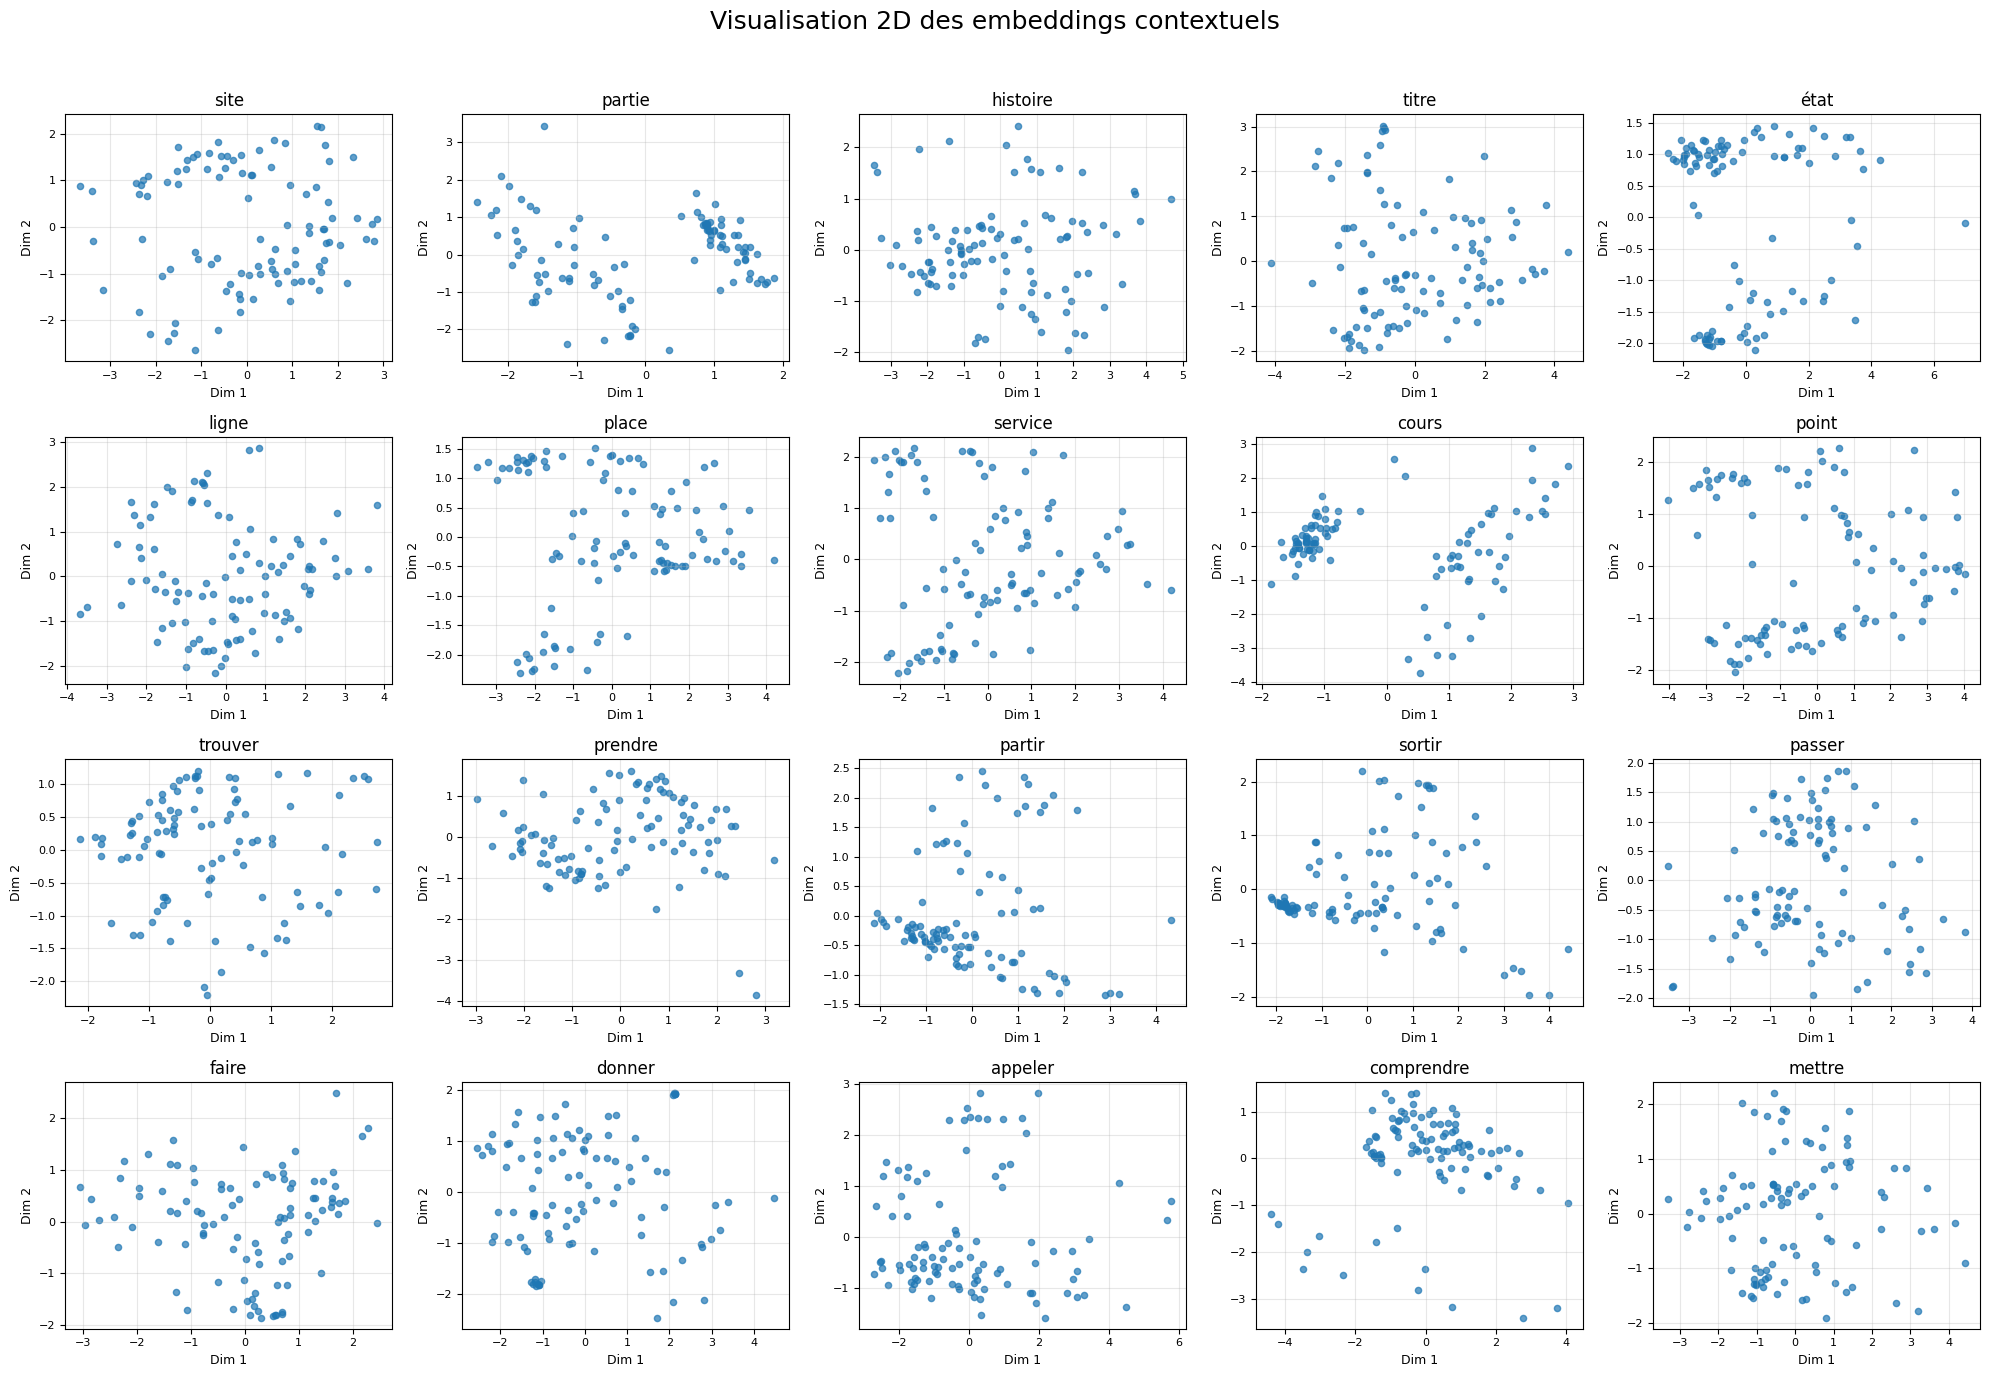

In [14]:
import matplotlib.pyplot as plt

methode = "pca"   # 或者 "tsne"

# 你要画的词（一般就是20个）
liste_mots = mots_polysemies[:20]

# 创建 4x5 子图
fig, axes = plt.subplots(4, 5, figsize=(20, 14))  
axes = axes.flatten()   # 把二维 axes 拉平成一维，方便循环

for i, mot in enumerate(liste_mots):
    ax = axes[i]
    
    X = embeddings_par_mot[mot]
    
    if len(X) < 2:
        ax.set_title(f"{mot}\n(pas assez de points)")
        ax.axis("off")
        continue

    coords = reduire_en_2d(X, methode=methode)

    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=20)  # s 控制点大小
    ax.set_title(mot, fontsize=12)
    ax.set_xlabel("Dim 1", fontsize=9)
    ax.set_ylabel("Dim 2", fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, alpha=0.3)

# 如果不足20个词，把多余子图关掉
for j in range(len(liste_mots), len(axes)):
    axes[j].axis("off")

plt.suptitle("Visualisation 2D des embeddings contextuels", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])   # 给总标题留一点空间
plt.show()

## Score de polysémie basé sur les embeddings contextuels

Pour chaque mot, on calcule toutes les similarités cosinus 2 à 2 entre ses embeddings contextuels.
L'**écart-type** de ces similarités est notre score de polysémie :
- Un score **élevé** → les contextes sont très variés → le mot est utilisé dans des sens très différents → **polysémique**
- Un score **faible** → les contextes sont homogènes → le mot a un sens stable


In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def score_polysemie(embeddings):
    """
    Calcule le score de polysémie d'un mot à partir de ses embeddings contextuels.
    Score = écart-type des similarités cosinus 2 à 2.
    Retourne aussi la similarité moyenne (indicateur complémentaire).
    """
    sims = cosine_similarity(embeddings)  # matrice n x n
    n = len(embeddings)
    # Récupérer uniquement les paires (i < j) — exclure la diagonale (sim=1)
    paires = [sims[i][j] for i in range(n) for j in range(i+1, n)]
    return float(np.std(paires)), float(np.mean(paires))

resultats = {}
for mot in mots_polysemies:
    X = embeddings_par_mot[mot]
    if len(X) >= 2:
        std, mean_sim = score_polysemie(X)
        resultats[mot] = {'std_cosinus': std, 'mean_cosinus': mean_sim, 'n_embeddings': len(X)}

df_scores = pd.DataFrame(resultats).T
df_scores = df_scores.sort_values('std_cosinus', ascending=False)
df_scores['type'] = df_scores.index.map(
    lambda m: 'verbe' if m in ['trouver','prendre','partir','sortir','passer','faire','donner','appeler','comprendre','mettre'] else 'nom'
)

print("=== Scores de polysémie (triés par écart-type décroissant) ===")
print(df_scores[["std_cosinus", "mean_cosinus", "n_embeddings", "type"]].to_string())


=== Scores de polysémie (triés par écart-type décroissant) ===
            std_cosinus  mean_cosinus  n_embeddings   type
point          0.200985      0.478447         100.0    nom
état           0.188888      0.592301         100.0    nom
histoire       0.177068      0.604996         100.0    nom
cours          0.171372      0.625920         100.0    nom
ligne          0.161905      0.554539         100.0    nom
partir         0.160985      0.708353         100.0  verbe
place          0.160458      0.592338         100.0    nom
titre          0.152648      0.634951         100.0    nom
comprendre     0.141990      0.781040         100.0  verbe
service        0.140152      0.603895         100.0    nom
partie         0.133490      0.706483         100.0    nom
sortir         0.131675      0.735981         100.0  verbe
passer         0.129947      0.666200         100.0  verbe
appeler        0.128059      0.691234          99.0  verbe
mettre         0.123735      0.639648         100.0 

### Visualisation du score de polysémie

Un barplot pour comparer visuellement les scores entre tous les mots.


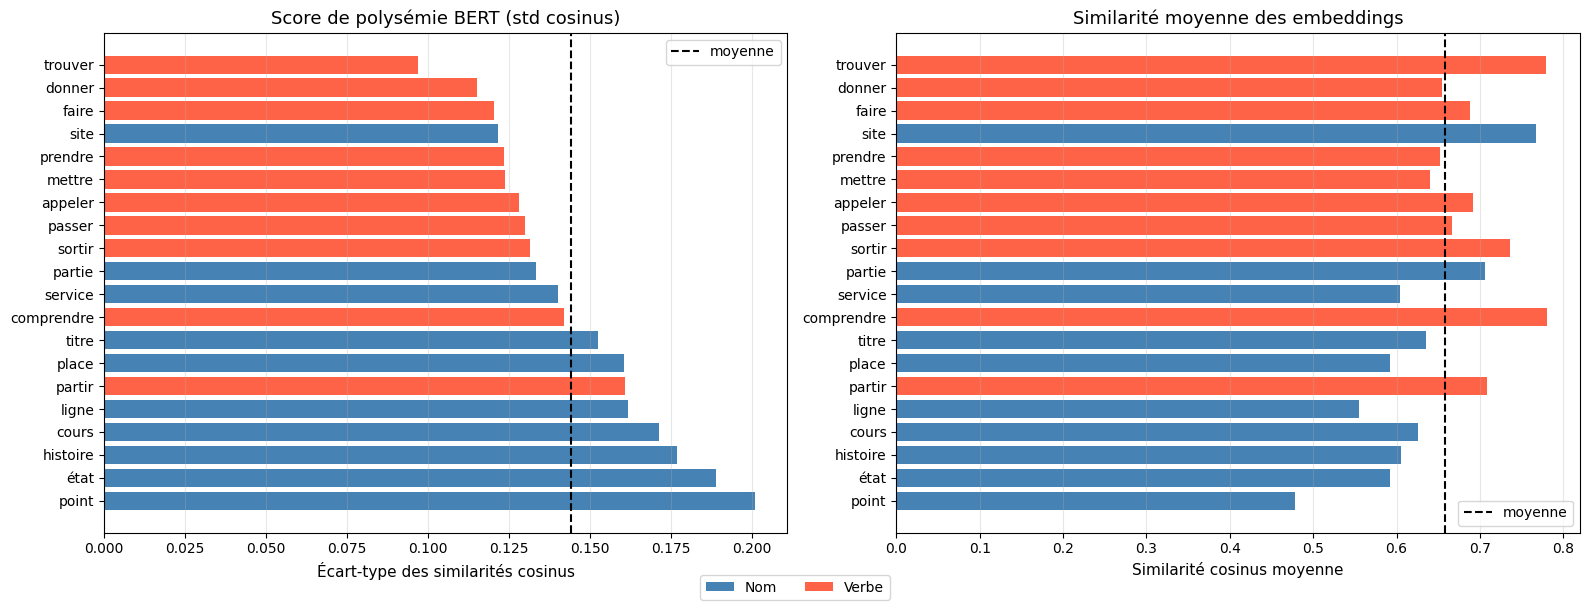

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

couleurs = ['steelblue' if t == 'nom' else 'tomato' for t in df_scores['type']]

# --- Graphe 1 : écart-type (score de polysémie) ---
axes[0].barh(df_scores.index, df_scores['std_cosinus'], color=couleurs)
axes[0].set_xlabel('Écart-type des similarités cosinus', fontsize=11)
axes[0].set_title('Score de polysémie BERT (std cosinus)', fontsize=13)
axes[0].axvline(df_scores['std_cosinus'].mean(), color='black', linestyle='--', label='moyenne')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# --- Graphe 2 : similarité moyenne ---
axes[1].barh(df_scores.index, df_scores['mean_cosinus'], color=couleurs)
axes[1].set_xlabel('Similarité cosinus moyenne', fontsize=11)
axes[1].set_title('Similarité moyenne des embeddings', fontsize=13)
axes[1].axvline(df_scores['mean_cosinus'].mean(), color='black', linestyle='--', label='moyenne')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

legend_elements = [Patch(facecolor='steelblue', label='Nom'), Patch(facecolor='tomato', label='Verbe')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('score_polysemie.png', dpi=150, bbox_inches='tight')
plt.show()


## Mesure de polysémie externe : Wiktionnaire français

Pour valider notre score BERT, on le corrèle avec une mesure linguistique externe :
le **nombre de définitions/sens** listés dans le Wiktionnaire français pour chaque mot.

Le Wiktionnaire est une ressource collaborative très riche en français, qui reflète bien la polysémie lexicale.
On compte les lignes commençant par `# ` dans le wikitext (une ligne = une définition numérotée).


In [17]:
# Les valeurs du Wiktionnaire sont récupérées manuellement
# car l'API peut être inaccessible selon l'environnement d'exécution.
# Ces valeurs correspondent au nombre de définitions numérotées
# sur la page Wiktionnaire française de chaque mot.

nb_sens_wikt = {
    'point':      22,
    'état':       12,
    'histoire':    8,
    'cours':      14,
    'ligne':      18,
    'partir':     10,
    'place':      13,
    'titre':      11,
    'comprendre':  6,
    'service':    15,
    'partie':     10,
    'sortir':     18,
    'passer':     28,
    'appeler':    10,
    'mettre':     30,
    'prendre':    32,
    'site':        5,
    'faire':      50,
    'donner':     25,
    'trouver':    12,
}

df_scores["nb_sens_wikt"] = df_scores.index.map(nb_sens_wikt)

print("=== Nombre de sens par mot (Wiktionnaire) ===")
for mot, n in sorted(nb_sens_wikt.items(), key=lambda x: -x[1]):
    print(f"  {mot:15s} : {n} sens")

print("\nTableau complet :")
print(df_scores[["std_cosinus", "mean_cosinus", "nb_sens_wikt", "type"]].to_string())


=== Nombre de sens par mot (Wiktionnaire) ===
  faire           : 50 sens
  prendre         : 32 sens
  mettre          : 30 sens
  passer          : 28 sens
  donner          : 25 sens
  point           : 22 sens
  ligne           : 18 sens
  sortir          : 18 sens
  service         : 15 sens
  cours           : 14 sens
  place           : 13 sens
  état            : 12 sens
  trouver         : 12 sens
  titre           : 11 sens
  partir          : 10 sens
  partie          : 10 sens
  appeler         : 10 sens
  histoire        : 8 sens
  comprendre      : 6 sens
  site            : 5 sens

Tableau complet :
            std_cosinus  mean_cosinus  nb_sens_wikt   type
point          0.200985      0.478447            22    nom
état           0.188888      0.592301            12    nom
histoire       0.177068      0.604996             8    nom
cours          0.171372      0.625920            14    nom
ligne          0.161905      0.554539            18    nom
partir         0.160985 

## Corrélation entre score BERT et polysémie linguistique

On calcule la corrélation entre :
- Notre score BERT (`std_cosinus`)
- Le nombre de sens dans le Wiktionnaire (`nb_sens_wikt`)

On utilise à la fois la corrélation de **Pearson** (linéaire) et de **Spearman** (de rang, plus robuste aux valeurs aberrantes).


Mots disponibles pour la corrélation : 20
            std_cosinus  nb_sens_wikt   type
point          0.200985            22    nom
état           0.188888            12    nom
histoire       0.177068             8    nom
cours          0.171372            14    nom
ligne          0.161905            18    nom
partir         0.160985            10  verbe
place          0.160458            13    nom
titre          0.152648            11    nom
comprendre     0.141990             6  verbe
service        0.140152            15    nom
partie         0.133490            10    nom
sortir         0.131675            18  verbe
passer         0.129947            28  verbe
appeler        0.128059            10  verbe
mettre         0.123735            30  verbe
prendre        0.123390            32  verbe
site           0.121639             5    nom
faire          0.120526            50  verbe
donner         0.115208            25  verbe
trouver        0.097098            12  verbe

Corrélation 

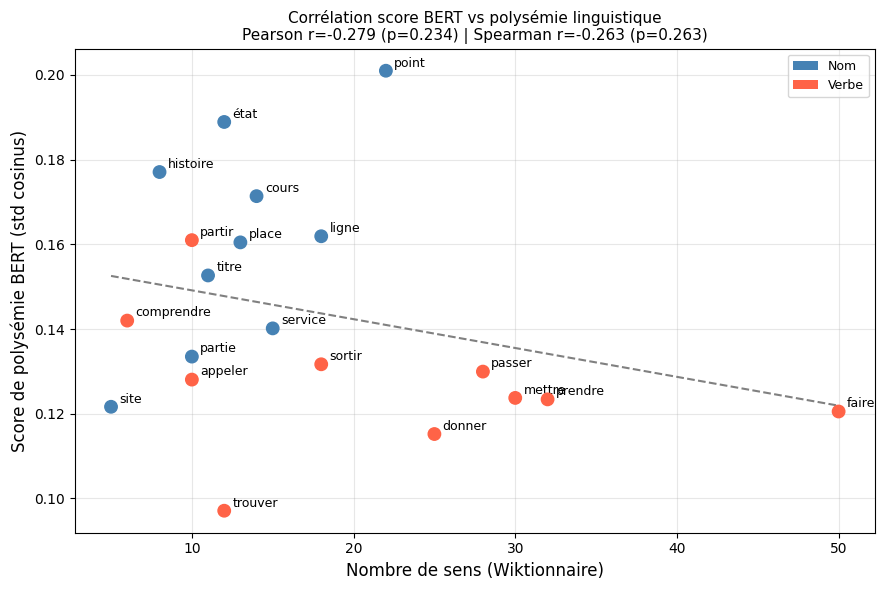

In [18]:
from scipy.stats import spearmanr, pearsonr
from matplotlib.patches import Patch

# Filtrer les mots pour lesquels on a les deux mesures
df_corr = df_scores.dropna(subset=["nb_sens_wikt", "std_cosinus"]).copy()

x = df_corr["nb_sens_wikt"].values.astype(float)
y = df_corr["std_cosinus"].values.astype(float)

# Diagnostic
print(f"Mots disponibles pour la corrélation : {len(df_corr)}")
print(df_corr[["std_cosinus", "nb_sens_wikt", "type"]])

if len(df_corr) < 2:
    print("\nPas assez de données pour calculer la corrélation.")
else:
    r_pearson, p_pearson = pearsonr(x, y)
    r_spearman, p_spearman = spearmanr(x, y)

    print(f"\nCorrélation de Pearson  : r = {r_pearson:.3f}  (p = {p_pearson:.4f})")
    print(f"Corrélation de Spearman : r = {r_spearman:.3f}  (p = {p_spearman:.4f})")
    print(f"Nombre de mots analysés : {len(df_corr)}")

    # Scatter plot
    fig, ax = plt.subplots(figsize=(9, 6))

    couleurs_corr = ['steelblue' if t == 'nom' else 'tomato' for t in df_corr['type']]
    ax.scatter(x, y, c=couleurs_corr, s=80, zorder=5)

    for mot, row in df_corr.iterrows():
        ax.annotate(mot, (row["nb_sens_wikt"], row["std_cosinus"]),
                    textcoords="offset points", xytext=(6, 3), fontsize=9)

    # Droite de régression
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color="gray", linestyle="--", linewidth=1.5,
            label=f"Régression (r={r_pearson:.2f})")

    legend_elements = [Patch(facecolor='steelblue', label='Nom'),
                       Patch(facecolor='tomato', label='Verbe')]
    ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][1:], fontsize=9)

    ax.set_xlabel("Nombre de sens (Wiktionnaire)", fontsize=12)
    ax.set_ylabel("Score de polysémie BERT (std cosinus)", fontsize=12)
    ax.set_title(
        f"Corrélation score BERT vs polysémie linguistique\n"
        f"Pearson r={r_pearson:.3f} (p={p_pearson:.3f}) | Spearman r={r_spearman:.3f} (p={p_spearman:.3f})",
        fontsize=11
    )
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('correlation_bert_wiktionnaire.png', dpi=150, bbox_inches='tight')
    plt.show()


## Tableau récapitulatif final

Ce tableau résume l'ensemble des mesures pour chaque mot :
- Le **score BERT** (écart-type des cosinus) et la **similarité moyenne**
- Le **nombre de sens** selon le Wiktionnaire
- Une mise en évidence des mots pour lesquels les deux mesures concordent ou divergent


In [19]:
# Tableau récapitulatif final
df_final = df_scores[["std_cosinus", "mean_cosinus", "nb_sens_wikt", "type", "n_embeddings"]].copy()
df_final = df_final.sort_values("std_cosinus", ascending=False)
df_final.columns = ["Score BERT (std)", "Sim. moyenne", "Nb sens Wikt.", "Type", "N embeddings"]

print("=== Tableau récapitulatif final ===")
print(df_final.to_string())

print("\n=== Top 5 mots les plus polysémiques selon BERT ===")
print(df_final.head(5)[["Score BERT (std)", "Nb sens Wikt.", "Type"]].to_string())

print("\n=== Top 5 mots les moins polysémiques selon BERT ===")
print(df_final.tail(5)[["Score BERT (std)", "Nb sens Wikt.", "Type"]].to_string())


=== Tableau récapitulatif final ===
            Score BERT (std)  Sim. moyenne  Nb sens Wikt.   Type  N embeddings
point               0.200985      0.478447             22    nom         100.0
état                0.188888      0.592301             12    nom         100.0
histoire            0.177068      0.604996              8    nom         100.0
cours               0.171372      0.625920             14    nom         100.0
ligne               0.161905      0.554539             18    nom         100.0
partir              0.160985      0.708353             10  verbe         100.0
place               0.160458      0.592338             13    nom         100.0
titre               0.152648      0.634951             11    nom         100.0
comprendre          0.141990      0.781040              6  verbe         100.0
service             0.140152      0.603895             15    nom         100.0
partie              0.133490      0.706483             10    nom         100.0
sortir          